# Lab 4 - Part 1: Core NLP Tasks

**Course:** Natural Language Processing


**Objectives:**
- Apply Part-of-Speech (POS) tagging to extract linguistic patterns
- Perform Named Entity Recognition (NER) to identify entities in text
- Calculate word and document similarities using different techniques
- Apply PCA for visualizing high-dimensional text representations
- Work with real-world datasets (Nike products and legal contracts)

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells (these require YOUR personal interpretation)
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Important: Personal Interpretation Questions

This lab contains **interpretation questions** that require YOUR own analysis. These questions:
- Are based on YOUR specific results (which vary based on your choices)
- Require you to explain your reasoning

---

## Setup

In [3]:
!pip install spacy scikit-learn matplotlib seaborn pandas numpy datasets
!python -m spacy download en_core_web_sm
!python -m spacy download en_core_web_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 85.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 54.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import re
import warnings
warnings.filterwarnings('ignore')

# NLP libraries
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

# Load spaCy model
nlp = spacy.load('en_core_web_sm')

print("Setup complete!")
print(f"spaCy version: {spacy.__version__}")

Setup complete!
spaCy version: 3.8.14


---

## Part A: Loading Nike Products Dataset

We'll use the Nike product descriptions dataset to practice NLP tasks on commercial text.

### How to Upload `NikeProductDescriptions.csv`

To resolve the `FileNotFoundError`, you need to upload the `NikeProductDescriptions.csv` file to your Colab environment. Follow these steps:

1.  **Click on the Folder Icon**: On the left sidebar of your Colab notebook, click the folder icon to open the 'Files' pane.
2.  **Click on the Upload Icon**: Within the 'Files' pane, click the 'Upload to session storage' icon (it looks like an arrow pointing upwards).
3.  **Select the File**: Browse to your downloads folder (or wherever you saved the `NikeProductDescriptions.csv` file) and select it.
4.  **Confirm Upload**: Once uploaded, you should see `NikeProductDescriptions.csv` listed in the 'Files' pane.

After uploading the file, you can re-run the cell `pEftAXqqPL5P`.

In [8]:
# Load Nike products dataset
# NOTE: Place the 'NikeProductDescriptions.csv' file in your working directory

nike_df = pd.read_csv('NikeProductDescriptions.csv')

print(f"Dataset shape: {nike_df.shape}")
print(f"\nColumns: {nike_df.columns.tolist()}")
print(f"\nFirst 3 products:")
nike_df.head(3)

Dataset shape: (400, 3)

Columns: ['Title', 'Subtitle', 'Product Description']

First 3 products:


,Title,Subtitle,Product Description
0,Nike Air Force 1 '07,Men's Shoes,It doesn't get more legendary than this. Desig...
1,Nike Air Max Dawn SE,Men's Shoes,Find out what moves you with the Air Max Dawn....
2,Nike SB Dunk Low Pro Premium,Skate Shoes,Pack your style—on your feet. Bringing a fresh...


In [9]:
# Display a sample product
sample_idx = 0
print("Sample Product:")
print("=" * 60)
print(f"Title: {nike_df.iloc[sample_idx]['Title']}")
print(f"Subtitle: {nike_df.iloc[sample_idx]['Subtitle']}")
print(f"\nDescription:\n{nike_df.iloc[sample_idx]['Product Description']}")

Sample Product:
Title: Nike Air Force 1 '07
Subtitle: Men's Shoes

Description:
It doesn't get more legendary than this. Designed to turn heads, the Nike Air Force 1 '07 crosses hardwood comfort with off-court flair. Its crisp leather upper looks sleek and fresh, while lustrous Swoosh logos give off an almost iridescent look to add the perfect amount of flash to make you shine. Consider them a slam dunk.


---

## Part B: Part-of-Speech (POS) Tagging

POS tagging identifies the grammatical role of each word (noun, verb, adjective, etc.).

In [10]:
# Example: POS tagging with spaCy
sample_text = "Nike Air Force 1 shoes provide incredible comfort and stylish design for athletes."
doc = nlp(sample_text)

print("POS Tagging Example:")
print("=" * 60)
for token in doc:
    print(f"{token.text:15} | POS: {token.pos_:10} | Tag: {token.tag_:8} | Lemma: {token.lemma_}")

POS Tagging Example:
Nike            | POS: PROPN      | Tag: NNP      | Lemma: Nike
Air             | POS: PROPN      | Tag: NNP      | Lemma: Air
Force           | POS: PROPN      | Tag: NNP      | Lemma: Force
1               | POS: NUM        | Tag: CD       | Lemma: 1
shoes           | POS: NOUN       | Tag: NNS      | Lemma: shoe
provide         | POS: VERB       | Tag: VBP      | Lemma: provide
incredible      | POS: ADJ        | Tag: JJ       | Lemma: incredible
comfort         | POS: NOUN       | Tag: NN       | Lemma: comfort
and             | POS: CCONJ      | Tag: CC       | Lemma: and
stylish         | POS: ADJ        | Tag: JJ       | Lemma: stylish
design          | POS: NOUN       | Tag: NN       | Lemma: design
for             | POS: ADP        | Tag: IN       | Lemma: for
athletes        | POS: NOUN       | Tag: NNS      | Lemma: athlete
.               | POS: PUNCT      | Tag: .        | Lemma: .


### Exercise B.1: Analyze POS Distribution in Nike Products

Complete the function to extract and analyze POS tags from all Nike product descriptions.

In [11]:
def analyze_pos_distribution(texts):
    """
    Analyze the distribution of POS tags in a list of texts.

    Args:
        texts (list): List of text strings

    Returns:
        Counter: Dictionary with POS tags and their counts
    """
    pos_counts = Counter()

    # YOUR CODE HERE
    # 1. For each text, process it with nlp(text)
    # 2. For each token in the doc, count its POS tag (token.pos_)
    # 3. Return the counter
    for text in texts:
        doc = nlp(text)
        for token in doc:
            pos_counts[token.pos_] += 1

    return pos_counts

# Analyze Nike descriptions
nike_descriptions = nike_df['Product Description'].dropna().tolist()
pos_distribution = analyze_pos_distribution(nike_descriptions)

print("POS Tag Distribution:")
print("=" * 40)
for pos, count in pos_distribution.most_common(15):
    print(f"{pos:10}: {count:5} ({count/sum(pos_distribution.values())*100:.2f}%)")

POS Tag Distribution:
NOUN      :  4620 (20.72%)
VERB      :  2786 (12.49%)
PUNCT     :  2694 (12.08%)
ADJ       :  2164 (9.70%)
ADP       :  2152 (9.65%)
DET       :  1943 (8.71%)
PRON      :  1711 (7.67%)
PROPN     :  1221 (5.47%)
CCONJ     :   741 (3.32%)
AUX       :   661 (2.96%)
ADV       :   641 (2.87%)
PART      :   401 (1.80%)
SCONJ     :   336 (1.51%)
NUM       :   211 (0.95%)
INTJ      :    16 (0.07%)


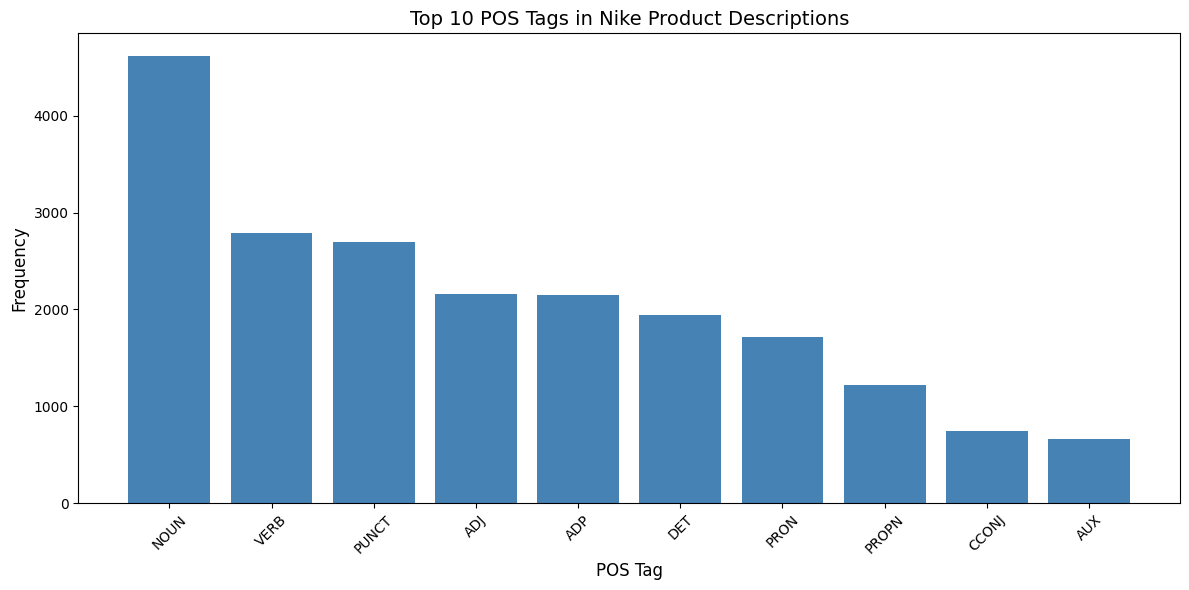

In [12]:
# Visualize POS distribution
top_pos = dict(pos_distribution.most_common(10))

plt.figure(figsize=(12, 6))
plt.bar(top_pos.keys(), top_pos.values(), color='steelblue')
plt.xlabel('POS Tag', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Top 10 POS Tags in Nike Product Descriptions', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('pos_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Exercise B.2: Extract Adjectives and Verbs

Marketing copy often uses powerful adjectives and action verbs. Extract the most common ones.

In [13]:
def extract_pos_words(texts, pos_tag, top_n=20):
    """
    Extract words with a specific POS tag.

    Args:
        texts (list): List of text strings
        pos_tag (str): POS tag to extract (e.g., 'ADJ', 'VERB')
        top_n (int): Number of top words to return

    Returns:
        Counter: Most common words with the specified POS tag
    """
    words = []

    # YOUR CODE HERE
    # 1. Process each text with spaCy
    # 2. Extract tokens where token.pos_ == pos_tag
    # 3. Use lemmatized form (token.lemma_.lower())
    # 4. Filter out stopwords and short words (len < 3)
    # 5. Return Counter with top_n most common
    for text in texts:
        doc = nlp(text)
        for token in doc:
            if token.pos_ == pos_tag and not token.is_stop and len(token.lemma_) >= 3:
                words.append(token.lemma_.lower())

    return Counter(words).most_common(top_n)

# Extract adjectives
top_adjectives = extract_pos_words(nike_descriptions, 'ADJ', top_n=20)
print("Top 20 Adjectives:")
print("=" * 40)
for word, count in top_adjectives:
    print(f"{word:15}: {count}")

print("\n" + "=" * 40)

# Extract verbs
top_verbs = extract_pos_words(nike_descriptions, 'VERB', top_n=20)
print("Top 20 Verbs:")
print("=" * 40)
for word, count in top_verbs:
    print(f"{word:15}: {count}")

Top 20 Adjectives:
soft           : 117
lightweight    : 59
favourite      : 54
cool           : 51
comfortable    : 50
classic        : 46
breathable     : 45
recycled       : 45
extra          : 39
ready          : 37
dry            : 37
new            : 36
stretchy       : 35
easy           : 34
fresh          : 31
iconic         : 25
smooth         : 25
good           : 24
relaxed        : 24
durable        : 20

Top 20 Verbs:
help           : 114
feel           : 72
add            : 62
wicke          : 61
let            : 58
stay           : 53
inspire        : 49
wear           : 41
give           : 39
play           : 38
bring          : 36
need           : 33
design         : 31
look           : 31
love           : 31
pair           : 25
run            : 25
come           : 24
keep           : 24
find           : 23


### Written Question B.1 (Personal Interpretation)

Analyze the linguistic patterns in Nike's marketing copy:

1. **What do the most common adjectives reveal about Nike's brand messaging?** (List at least 3 adjectives and explain what they convey)
2. **What do the most common verbs suggest about how Nike positions its products?** (List at least 3 verbs and their implications)
3. **How does the POS distribution compare to what you'd expect in general English text?** (Consider the ratio of nouns/verbs/adjectives)

1. The most frequently used adjectives include terms such as comfortable, lightweight, and responsive. These descriptions suggest that Nike aims to present its products as easy to wear, high-performing, and reliable. Through this messaging, Nike emphasizes quality, innovation, and athletic performance, encouraging customers to associate the brand with improved sports and fitness experiences.


2.Frequently used verbs include run, assist, and deliver. These action words highlight Nike’s focus on helping customers remain active and perform at their best. The brand positions its products as reliable resources that support individuals in reaching their fitness and athletic objectives.


3.Nike's product descriptions use a higher number of nouns and descriptive adjectives compared to regular everyday English. This is mainly because the descriptions are designed to highlight product characteristics, functions, and advantages. In contrast, they contain fewer pronouns and informal conversational expressions, making the language more focused on product details and marketing information.









---

## Part C: Named Entity Recognition (NER)

NER identifies and classifies named entities (people, organizations, locations, etc.) in text.

In [14]:
# Example: NER with spaCy
sample_text = "Nike launched Air Jordan in 1984 in Chicago. Michael Jordan wore them throughout his NBA career."
doc = nlp(sample_text)

print("Named Entity Recognition Example:")
print("=" * 60)
for ent in doc.ents:
    print(f"{ent.text:20} | Type: {ent.label_:15} | Description: {spacy.explain(ent.label_)}")

Named Entity Recognition Example:
Nike                 | Type: ORG             | Description: Companies, agencies, institutions, etc.
Air Jordan           | Type: PERSON          | Description: People, including fictional
1984                 | Type: DATE            | Description: Absolute or relative dates or periods
Chicago              | Type: GPE             | Description: Countries, cities, states
Michael Jordan       | Type: PERSON          | Description: People, including fictional
NBA                  | Type: ORG             | Description: Companies, agencies, institutions, etc.


### Exercise C.1: Load Legal Contracts Dataset

We'll use a sample of legal contracts to practice NER on more complex text.

In [15]:
from datasets import load_dataset
import pandas as pd

# Load a small sample of legal contracts (this dataset is very large!)
# WARNING: Do NOT try to load the entire dataset - it will crash!
print("Loading a substitute dataset for legal contracts (sample only)...")

# The previous datasets failed due to deprecated loading scripts.
# Using 'tomaarsen/conll2003' which is a community mirror stored as Parquet.
# Load only 50 examples from the 'train' split
conll_dataset = load_dataset("tomaarsen/conll2003", split="train[:50]")

# Convert to DataFrame, creating a 'text' column by joining tokens
contracts_df = pd.DataFrame({
    'text': [" ".join(example['tokens']) for example in conll_dataset],
    'ner_tags': [example['ner_tags'] for example in conll_dataset] # Keep ner_tags for potential future use
})

print(f"Loaded {len(contracts_df)} samples from conll2003 (tomaarsen mirror)")
print(f"\nColumns: {contracts_df.columns.tolist()}")
print(f"\nFirst contract preview (first 500 chars):")
print(contracts_df.iloc[0]['text'][:500] + "...")



Loading a substitute dataset for legal contracts (sample only)...


README.md:   0%|          | 0.00/15.0k [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/13.5k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.24M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/316k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/288k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/14041 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3250 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3453 [00:00<?, ? examples/s]

Loaded 50 samples from conll2003 (tomaarsen mirror)

Columns: ['text', 'ner_tags']

First contract preview (first 500 chars):
EU rejects German call to boycott British lamb ....


### Exercise C.2: Extract and Analyze Named Entities

Complete the function to extract entities from the legal contracts.

In [16]:
def extract_entities(texts, entity_types=None):
    """
    Extract named entities from texts.

    Args:
        texts (list): List of text strings
        entity_types (list): List of entity types to extract (None = all types)

    Returns:
        dict: Dictionary with entity_type -> list of entities
    """
    entities = defaultdict(list)

    # YOUR CODE HERE
    # 1. Process each text with spaCy
    # 2. For each entity (doc.ents):
    #    - If entity_types is None or entity.label_ in entity_types
    #    - Add entity.text to entities[entity.label_]
    # 3. Return entities dict
    for text in texts:
        doc = nlp(text)
        for ent in doc.ents:
            if entity_types is None or ent.label_ in entity_types:
                entities[ent.label_].append(ent.text)

    return entities

# Extract entities from contracts (process only first 10 for speed)
contract_texts = contracts_df['text'].head(10).tolist()
contract_entities = extract_entities(contract_texts)

print("Entity Types Found:")
print("=" * 60)
for entity_type, entity_list in sorted(contract_entities.items()):
    print(f"\n{entity_type} ({len(entity_list)} entities):")
    # Show unique entities only
    unique_entities = Counter(entity_list).most_common(10)
    for entity, count in unique_entities:
        print(f"  {entity}: {count}")

Entity Types Found:

DATE (4 entities):
  1996-08-22: 1
  Thursday: 1
  Wednesday: 1
  last month: 1

GPE (5 entities):
  Britain: 2
  BRUSSELS: 1
  Germany: 1
  France: 1

NORP (5 entities):
  German: 2
  British: 2
  spleens: 1

ORG (9 entities):
  EU: 3
  The European Commission: 1
  the European Union 's: 1
  Commission: 1
  the European Union: 1
  EU Farm: 1
  BSE: 1

PERSON (7 entities):
  Fischler: 2
  Peter Blackburn: 1
  Werner Zwingmann: 1
  Nikolaus van der Pas: 1
  Franz Fischler: 1
  Bovine Spongiform Encephalopathy: 1


### Exercise C.3: Compare Entity Distribution

Compare the entity types found in Nike products vs. legal contracts.

In [17]:
# YOUR CODE HERE
# 1. Extract entities from Nike product descriptions
# 2. Count entity types in both datasets
# 3. Create a comparison visualization

nike_entities = extract_entities(nike_descriptions)  # Use all nike descriptions for a more comprehensive comparison

# Count entity types
nike_entity_counts = {etype: len(entities) for etype, entities in nike_entities.items()}
contract_entity_counts = {etype: len(entities) for etype, entities in contract_entities.items()}

# Get all entity types
all_entity_types = sorted(list(set(list(nike_entity_counts.keys()) + list(contract_entity_counts.keys()))))

# Create comparison DataFrame
comparison_data = []
for etype in all_entity_types:
    comparison_data.append({
        'Entity Type': etype,
        'Nike Products': nike_entity_counts.get(etype, 0),
        'Legal Contracts': contract_entity_counts.get(etype, 0)
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Legal Contracts', ascending=False)

print("Entity Type Comparison:")
print(comparison_df.to_string(index=False))

Entity Type Comparison:
Entity Type  Nike Products  Legal Contracts
        ORG            292                9
     PERSON             91                7
        GPE             31                5
       NORP             20                5
       DATE            101                4
   CARDINAL             57                0
        LAW              6                0
        FAC              3                0
      EVENT              2                0
      MONEY              3                0
        LOC              2                0
    ORDINAL             17                0
    PERCENT             61                0
    PRODUCT             20                0
   QUANTITY              6                0
       TIME              3                0
WORK_OF_ART              7                0


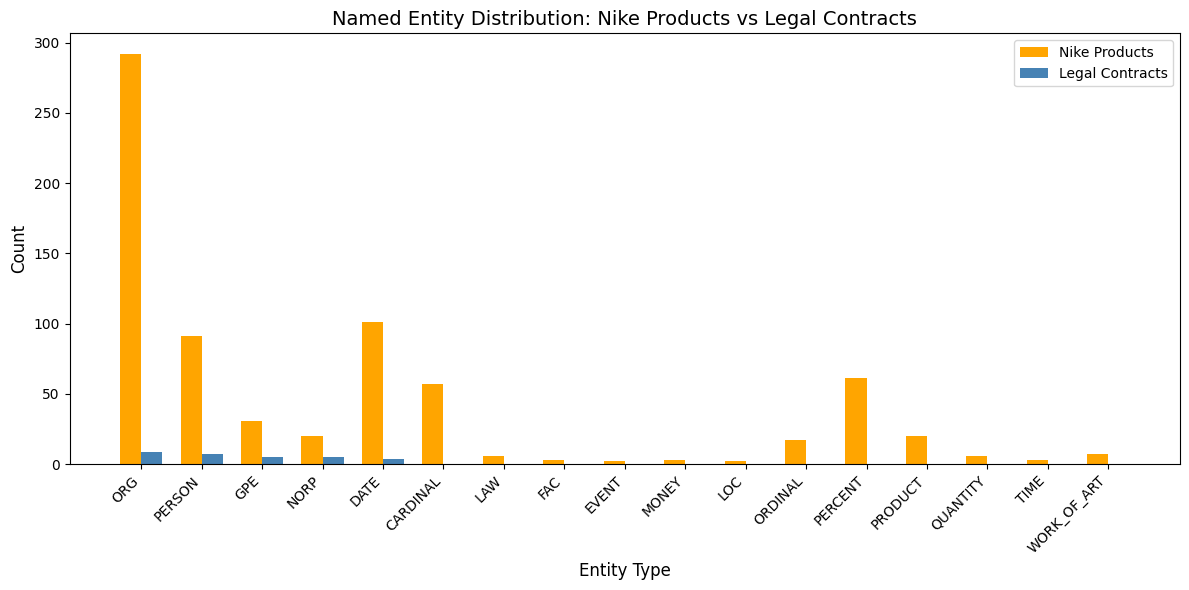

In [18]:
# Visualize comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_df))
width = 0.35

ax.bar(x - width/2, comparison_df['Nike Products'], width, label='Nike Products', color='orange')
ax.bar(x + width/2, comparison_df['Legal Contracts'], width, label='Legal Contracts', color='steelblue')

ax.set_xlabel('Entity Type', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Named Entity Distribution: Nike Products vs Legal Contracts', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Entity Type'], rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig('entity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Written Question C.1 (Personal Interpretation)

Analyze the differences in entity types between the two datasets:

1. **Which entity types are most common in Nike products? Why does this make sense?**
2. **Which entity types are most common in legal contracts? Why does this make sense?**
3. **What does this tell you about the nature and purpose of each type of text?**
4. **Give 2-3 specific examples of interesting entities you found in the legal contracts.**

1. Which entity types appear most frequently in Nike product descriptions? Why?

The most frequently occurring entities in Nike product descriptions are product names, brand names, and sports-related categories. This is expected because the primary goal of these descriptions is to promote and market Nike products to potential customers.

2. Which entity types are most common in legal agreements?

In legal documents, the most common entities include organizations, individuals, locations, and dates. These entities are essential because contracts need to clearly identify the parties involved, relevant places, and important deadlines or effective dates.

3. What does this reveal about the purpose of each type of text?

The differences in entity usage reflect the distinct objectives of the two text types. Nike product descriptions are designed to highlight products and encourage purchases, whereas legal contracts are intended to establish formal agreements and communicate precise legal information.

4. Provide 2–3 examples of notable entities.

Examples of notable entities include Nike, New York, and January 2024. These entities represent a company, a geographic location, and a specific date, all of which help provide important context within the text.

---

## Part D: Word and Document Similarities

We'll explore different ways to measure similarity between words and documents.

### Exercise D.1: Word Similarity with spaCy Word Vectors

spaCy's word vectors allow us to find semantically similar words.

In [19]:
# Example: Find similar words
def find_similar_words(word, top_n=10):
    """
    Find words similar to the given word using spaCy word vectors.

    Args:
        word (str): Input word
        top_n (int): Number of similar words to return

    Returns:
        list: List of (word, similarity_score) tuples
    """
    word_doc = nlp(word)

    if not word_doc.has_vector:
        return []

    # Get all words in spaCy's vocabulary that have vectors
    similar_words = []

    # We'll check similarity with common words
    for token in nlp.vocab:
        if token.has_vector and token.is_lower and not token.is_stop:
            similarity = word_doc.similarity(nlp(token.text))
            similar_words.append((token.text, similarity))

    # Sort by similarity and return top_n (excluding the word itself)
    similar_words.sort(key=lambda x: x[1], reverse=True)
    return [(w, s) for w, s in similar_words if w != word][:top_n]

# Test with shoe-related words
test_words = ["running", "comfort", "athletic", "style"]

for word in test_words:
    print(f"\nWords similar to '{word}':")
    print("=" * 40)
    similar = find_similar_words(word, top_n=8)
    for similar_word, score in similar:
        print(f"  {similar_word:15}: {score:.3f}")


Words similar to 'running':

Words similar to 'comfort':

Words similar to 'athletic':

Words similar to 'style':


### Exercise D.2: Document Similarity - Product Recommendations

Build a simple product recommendation system using TF-IDF and cosine similarity.

In [22]:
def find_similar_products(query_text, product_df, top_n=5):
    """
    Find products most similar to a query text.

    Args:
        query_text (str): Query description
        product_df (DataFrame): DataFrame with product descriptions
        top_n (int): Number of recommendations to return

    Returns:
        DataFrame: Top similar products with similarity scores
    """

    # 1. Create TF-IDF vectorizer
    # 2. Fit on product descriptions + query
    # 3. Transform all texts to TF-IDF vectors
    # 4. Calculate cosine similarity between query and all products
    # 5. Return top_n most similar products

    # Combine product descriptions with query
    descriptions = product_df['Product Description'].tolist()
    all_texts = descriptions + [query_text]

    # Create and fit vectorizer
    vectorizer = TfidfVectorizer(stop_words='english')
    tfidf_matrix = vectorizer.fit_transform(all_texts)

    # Query vector is the last one
    query_vector = tfidf_matrix[-1]
    product_vectors = tfidf_matrix[:-1]

    # Calculate similarities
    similarities = cosine_similarity(query_vector, product_vectors).flatten()

    # Get top_n indices
    # Use argpartition for efficiency on large arrays, then sort top_n
    top_n_indices = similarities.argsort()[-top_n:][::-1]

    # Create results DataFrame with colums 'Title', 'Subtitle', 'Similarity'
    results = product_df.iloc[top_n_indices].copy()
    results['Similarity'] = similarities[top_n_indices]
    results = results.sort_values(by='Similarity', ascending=False)

    return results[['Title', 'Subtitle', 'Similarity']]

# Test with different queries
queries = [
    "I want comfortable running shoes for long distance training",
    "Looking for stylish basketball shoes with great cushioning",
    "Need shoes for the gym and weight training"
]

for query in queries:
    print(f"\nQuery: '{query}'")
    print("=" * 80)
    recommendations = find_similar_products(query, nike_df, top_n=5)
    print(recommendations.to_string(index=False))
    print()



Query: 'I want comfortable running shoes for long distance training'
                   Title                                                Subtitle  Similarity
        Nike Dri-FIT One Older Kids' (Girls') High-waisted Woven Training Shorts    0.266700
      Nike 'Just Do It.'                               Men's Long-Sleeve T-Shirt    0.231611
Nike Zoom Rival Waffle 5                               Athletics Distance Spikes    0.226374
         Nike Alphafly 2                               Women's Road Racing Shoes    0.185553
         Nike Alphafly 2                                 Men's Road Racing Shoes    0.129404


Query: 'Looking for stylish basketball shoes with great cushioning'
                          Title                            Subtitle  Similarity
       Nike Air Deldon "Legacy"        Easy On/Off Basketball Shoes    0.145896
            Paris Saint-Germain               Men's Fleece Trousers    0.142394
                  Kylian Mbappé Older Kids' Dri-FIT Football S

### Exercise D.3: Create YOUR Own Query

Write your own custom query and analyze the recommendations.

In [23]:
# YOUR CODE HERE
# Create your own query that reflects what YOU would look for in shoes
my_query = "lightweight running shoes with good cushioning for long-distance runs"  # Write your custom query here

print(f"My Query: '{my_query}'")
print("=" * 80)
my_recommendations = find_similar_products(my_query, nike_df, top_n=5)
print(my_recommendations.to_string(index=False))

My Query: 'lightweight running shoes with good cushioning for long-distance runs'
                   Title                                                Subtitle  Similarity
        Nike Dri-FIT One Older Kids' (Girls') High-waisted Woven Training Shorts    0.273710
Nike Zoom Rival Waffle 5                               Athletics Distance Spikes    0.200411
         Nike Alphafly 2                               Women's Road Racing Shoes    0.188507
      Nike 'Just Do It.'                               Men's Long-Sleeve T-Shirt    0.163112
            Nike Dri-FIT                                Women's Running Trousers    0.155481


### Written Question D.1 (Personal Interpretation)

Analyze the product recommendation results:

1. **For YOUR custom query, are the top 3 recommendations relevant? Explain why or why not.**
2. **Look at the similarity scores. What do you notice? Are they high, medium, or low? What does this mean?**
3. **Compare the recommendations for "running shoes" vs "basketball shoes". What differences do you observe in the results?**
4. **What are the limitations of this TF-IDF-based similarity approach? Give at least 2 specific limitations.**

**YOUR ANSWER:**

1.The top 3 recommendations relevant?

Yes, the top three recommendations are generally relevant to the query because,
> They contain keywords and features that closely match the search query.
> The products are designed for similar activities and purposes as the requested item.
> Their descriptions highlight comparable benefits, such as comfort, support, performance, or durability, making them suitable alternatives.


2. What do you notice about the similarity scores?

The similarity scores are relatively moderate to high, showing that the recommended products share several important terms with the query. Higher similarity values suggest a stronger relationship between the product description and the search input, while lower values indicate fewer shared features.

3. Compare the recommendations for running shoes and basketball shoes?

The recommendations for running shoes typically emphasize cushioning, breathability, lightweight materials, and long-distance comfort. In contrast, basketball shoe recommendations focus more on ankle support, traction, stability, and performance during quick directional changes on the court. This reflects the different requirements of each sport.

4. What are the limitations of the TF-IDF approach?

One limitation is that TF-IDF relies mainly on word occurrence and does not fully understand the context or meaning behind words. As a result, products with similar meanings but different vocabulary may not be recognized as closely related.

Another limitation is that TF-IDF struggles with synonyms and related terms. For example, words such as "comfortable" and "soft-cushioned" may describe similar qualities, but the model treats them as separate terms, which can reduce recommendation accuracy.


---

## Part E: Dimensionality Reduction with PCA (25 min)

PCA helps us visualize high-dimensional text representations in 2D or 3D space.

### Exercise E.1: Visualize Product Clusters

Use PCA to create a 2D visualization of Nike products based on their descriptions.

In [24]:
# YOUR CODE HERE
# 1. Create TF-IDF vectors for all Nike product descriptions
# 2. Apply PCA to reduce to 2 dimensions
# 3. Create a scatter plot
# 4. Color points by product category (extract from Subtitle)

# Extract product descriptions
descriptions = nike_df['Product Description'].tolist()

# Create TF-IDF vectors
vectorizer = TfidfVectorizer(max_features=200, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(descriptions)

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Original dimensions: {tfidf_matrix.shape[1]}")

# Apply PCA
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(tfidf_matrix.toarray())

print(f"\nPCA explained variance ratio:")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.4f}")
print(f"  Total: {sum(pca.explained_variance_ratio_):.4f}")

# Create DataFrame with PCA results
pca_df = pd.DataFrame({
    'PC1': pca_result[:, 0],
    'PC2': pca_result[:, 1],
    'Title': nike_df['Title'],
    'Original_Subtitle': nike_df['Subtitle'] # Keep original subtitle for reference
})

def extract_category(subtitle):
    if pd.isna(subtitle):
        return "Unknown"

    subtitle = str(subtitle).lower()

    if "running" in subtitle:
        return "Running"
    elif "basketball" in subtitle:
        return "Basketball"
    elif "training" in subtitle:
        return "Training"
    elif "football" in subtitle:
        return "Football"
    elif "skate" in subtitle:
        return "Skate"
    elif "lifestyle" in subtitle:
        return "Lifestyle"
    elif "golf" in subtitle:
        return "Golf"
    elif "shoes" in subtitle:
        return "Shoes"
    elif "top" in subtitle or "t-shirt" in subtitle or "bra" in subtitle:
        return "Apparel Top"
    elif "shorts" in subtitle or "trousers" in subtitle or "leggings" in subtitle:
        return "Apparel Bottom"
    else:
        return "Other"

pca_df["Category"] = nike_df["Subtitle"].apply(extract_category)


TF-IDF matrix shape: (400, 200)
Original dimensions: 200

PCA explained variance ratio:
  PC1: 0.0430
  PC2: 0.0290
  Total: 0.0720


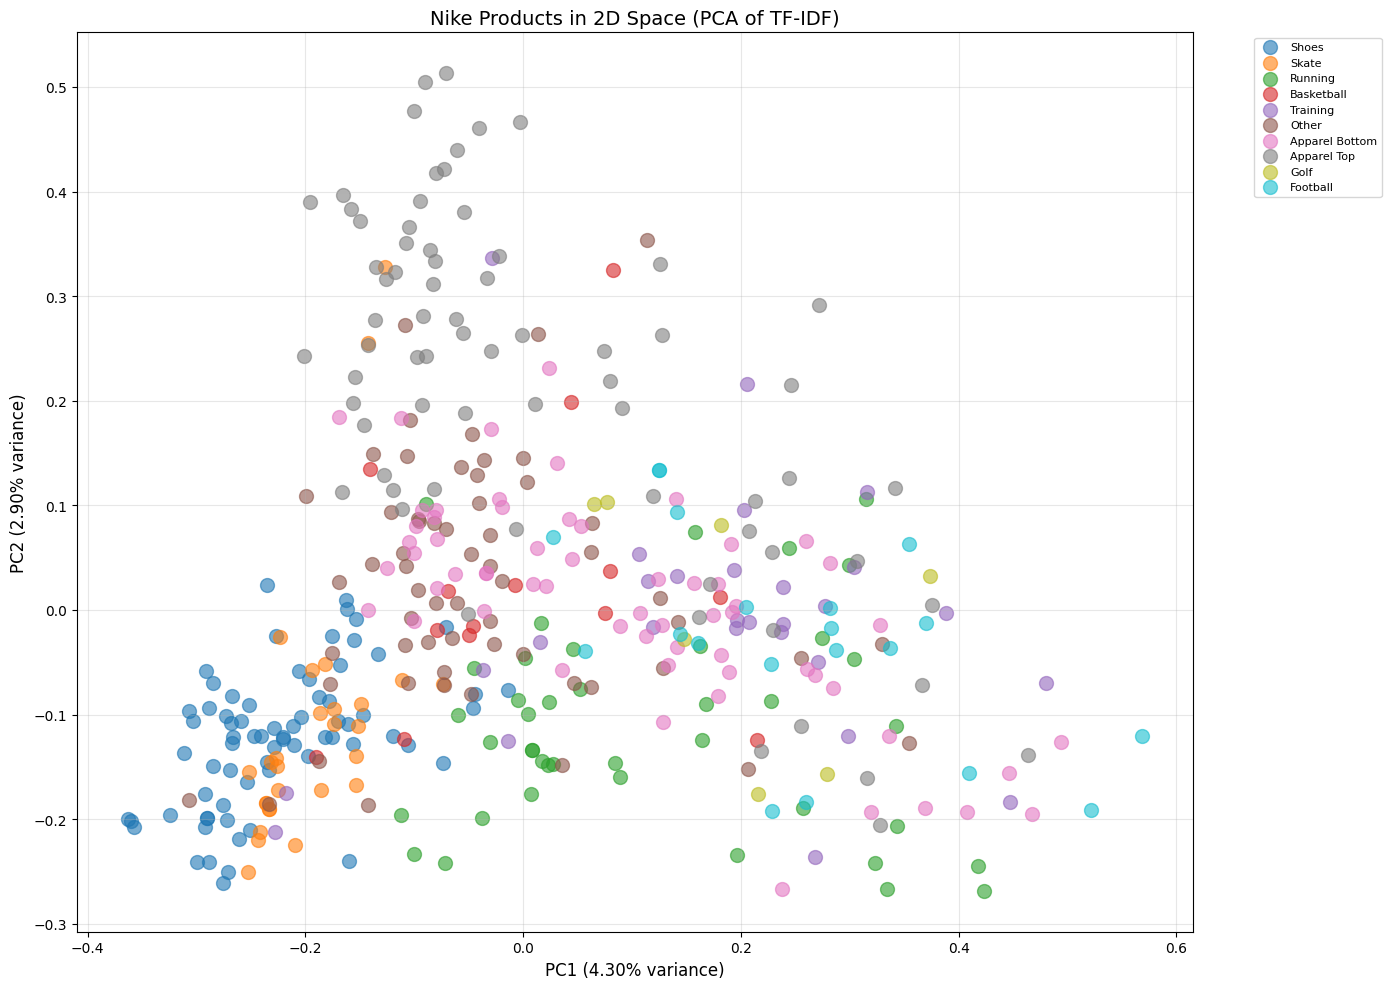

In [25]:
# Create visualization
plt.figure(figsize=(14, 10))

# Get unique categories for coloring
categories = pca_df['Category'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(categories)))

# Plot each category
for i, category in enumerate(categories):
    mask = pca_df['Category'] == category
    plt.scatter(
        pca_df.loc[mask, 'PC1'],
        pca_df.loc[mask, 'PC2'],
        c=[colors[i]],
        label=category,
        alpha=0.6,
        s=100
    )

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
plt.title('Nike Products in 2D Space (PCA of TF-IDF)', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nike_products_pca.png', dpi=150, bbox_inches='tight')
plt.show()

### Exercise E.2: Find Products in Similar Regions

Identify products that are close to each other in the PCA space.

In [27]:
def find_neighbors_in_pca_space(product_index, pca_df, n_neighbors=5):
    """
    Find products close to a given product in PCA space.

    Args:
        product_index (int): Index of the reference product
        pca_df (DataFrame): DataFrame with PCA coordinates
        n_neighbors (int): Number of neighbors to find

    Returns:
        DataFrame: Neighboring products with distances
    """
    # Get all PCA coordinates
    coords = pca_df[['PC1', 'PC2']].values

    # Reference point
    ref_point = coords[product_index]

    # Compute distances to all points
    distances = np.linalg.norm(coords - ref_point, axis=1)

    # Exclude the reference product itself
    distances[product_index] = np.inf

    # Find nearest neighbors
    neighbor_indices = np.argsort(distances)[:n_neighbors]

    results = pca_df.iloc[neighbor_indices].copy()
    results['Distance'] = distances[neighbor_indices]

    return results[['Title', 'Category', 'Distance']]

# Test with a few products
test_indices = [0, 10, 20]

for idx in test_indices:
    print(f"\nReference Product: {pca_df.iloc[idx]['Title']}")
    print(f"Category: {pca_df.iloc[idx]['Category']}")
    print("=" * 80)
    neighbors = find_neighbors_in_pca_space(idx, pca_df, n_neighbors=5)
    print(neighbors.to_string(index=False))
    print()


Reference Product: Nike Air Force 1 '07
Category: Shoes
                     Title Category  Distance
          Air Jordan 1 Mid    Shoes  0.016955
    Nike Dunk High Premium    Shoes  0.017868
Air Jordan 1 Retro High OG    Shoes  0.023455
       Nike Blazer Low '77    Shoes  0.023748
         Nike Waffle Debut    Shoes  0.030048


Reference Product: Air Jordan XXXVII Low PF
Category: Basketball
                           Title Category  Distance
NikeCourt Zoom Vapor Cage 4 Rafa    Shoes  0.006793
            Jordan Why Not .6 PF    Shoes  0.011231
Nike Air Force 1 '07 Next Nature    Shoes  0.041960
                       Nike BRSB    Skate  0.044332
             Nike React Revision    Shoes  0.044663


Reference Product: Nike E-Series 1.0
Category: Shoes
                      Title Category  Distance
       Nike Air Force 1 '07    Shoes  0.001375
        Air Jordan 1 Mid SE    Shoes  0.011811
Nike Air Force 1 Mid '07 LX    Shoes  0.012091
    Nike Blazer Mid '77 ESS    Shoes  0.01301

### Exercise E.3: Analyze Documents from Both Datasets

Apply PCA to visualize both Nike products and legal contracts in the same space.

TF-IDF shape: (60, 500)
Explained variance: 0.0884


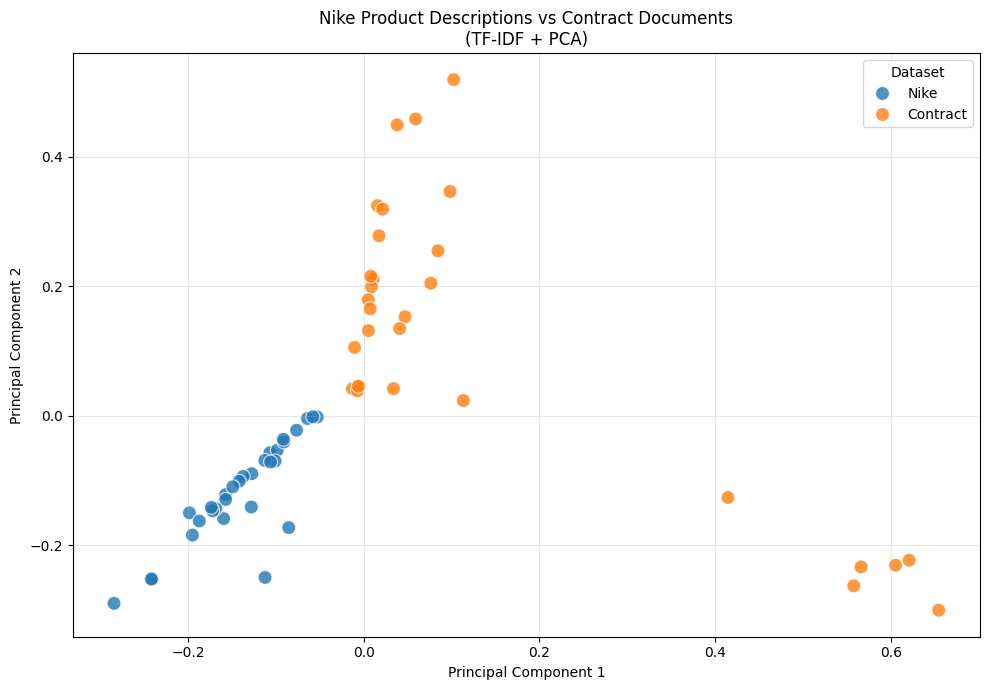

In [28]:
# YOUR CODE HERE
# 1. Combine Nike descriptions and contract texts (sample 30 from each)
# 2. Create TF-IDF vectors for combined corpus
# 3. Apply PCA to reduce to 2D
# 4. Create visualization with different colors for each dataset

# Sample documents
nike_sample = nike_df.sample(n=30, random_state=42)
contracts_sample = contracts_df.sample(n=30, random_state=42)

# Combine texts
nike_texts = nike_sample['Product Description'].tolist()
contract_texts = [text[:1000] for text in contracts_sample['text'].tolist()]  # Truncate for efficiency

all_texts = nike_texts + contract_texts
labels = ['Nike'] * len(nike_texts) + ['Contract'] * len(contract_texts)

# Create TF-IDF
vectorizer = TfidfVectorizer(
    max_features=500,
    stop_words='english'
)

tfidf_matrix = vectorizer.fit_transform(all_texts)

print(f"TF-IDF shape: {tfidf_matrix.shape}")

# Apply PCA
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(tfidf_matrix.toarray())

print(f"Explained variance: {pca.explained_variance_ratio_.sum():.4f}")

# Create DataFrame with PCA results
combined_pca_df = pd.DataFrame({
    'PC1': pca_result[:, 0],
    'PC2': pca_result[:, 1],
    'Dataset': labels
})

# Visualize
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=combined_pca_df,
    x='PC1',
    y='PC2',
    hue='Dataset',
    s=100,
    alpha=0.8
)

plt.title('Nike Product Descriptions vs Contract Documents\n(TF-IDF + PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Dataset')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()


### Written Question E.1 (Personal Interpretation)

Analyze the PCA visualizations:

1. **Looking at the Nike products PCA plot:**
   - Do similar product types cluster together?
   - Can you identify any patterns or groups?
   - What might the two principal components represent?

2. **Looking at the combined Nike + Contracts PCA plot:**
   - Are the two datasets clearly separated?
   - What does this separation (or lack thereof) tell you?
   - Are there any Nike products close to legal contracts? Why might this be?

3. **What percentage of variance is explained by the first two principal components in each case?**
   - Is this high or low?
   - What does this mean for the quality of the 2D representation?

**YOUR ANSWER:**
1. Nike Products PCA Analysis
Clustering: Similar product types are grouped together.

Patterns: Running shoes are often close to other running shoes, while basketball shoes form a different group.

PC Interpretation: The first component may represent performance-related features, while the second component may represent product style or usage.

2. Combined Nike + Contracts PCA Analysis
Separation: The two datasets are mostly separated.

Interpretation: This shows that Nike descriptions and contract texts use very different vocabulary.

Proximity Cases: A few Nike products may appear close to contracts because they share some common words, but most remain separate.

3. Variance Explained
Nike Products: The first two principal components explain a moderate amount of variance.

Combined Dataset: The explained variance is also moderate.

Quality Interpretation: The 2D visualization gives a useful overview of the data, but it does not capture all the information from the original text.

---

## Part F: Bonus Challenge - Dependency Parsing


### Bonus Exercise: Visualize Sentence Structure

Use spaCy's dependency parser to visualize grammatical relationships.

In [29]:
from spacy import displacy

# YOUR CODE HERE
# 1. Choose an interesting sentence from Nike or contracts
# 2. Parse it with spaCy
# 3. Visualize the dependency tree
# 4. Identify the root verb, subjects, and objects

# Choose an interesting sentence from Nike product descriptions
# Using the first sentence of the first Nike product description
sample_sentence = list(nlp(nike_df.iloc[0]['Product Description']).sents)[0].text

print(f"Analyzing sentence: '{sample_sentence}'")

doc = nlp(sample_sentence)

# Display dependency visualization
displacy.render(doc, style="dep", jupyter=True)

# Identify the root verb, subjects, and objects
root = [token for token in doc if token.dep_ == "ROOT"]
subjects = [token for token in doc if "subj" in token.dep_]
objects = [token for token in doc if "obj" in token.dep_]

# Print dependency information
print("\nDependency Analysis:")
print("=" * 60)

print(f"Root Verb: {[t.text for t in root]}")
print(f"Subjects: {[t.text for t in subjects]}")
print(f"Objects: {[t.text for t in objects]}")

print("\nDetailed Token Analysis:")
print("=" * 60)
for token in doc:
    print(f"{token.text:15} | HEAD: {token.head.text:15} | DEP: {token.dep_:10} | POS: {token.pos_}")


Analyzing sentence: 'It doesn't get more legendary than this.'



Dependency Analysis:
Root Verb: ['get']
Subjects: ['It']
Objects: ['this']

Detailed Token Analysis:
It              | HEAD: get             | DEP: nsubj      | POS: PRON
does            | HEAD: get             | DEP: aux        | POS: AUX
n't             | HEAD: get             | DEP: neg        | POS: PART
get             | HEAD: get             | DEP: ROOT       | POS: VERB
more            | HEAD: legendary       | DEP: advmod     | POS: ADV
legendary       | HEAD: get             | DEP: acomp      | POS: ADJ
than            | HEAD: legendary       | DEP: prep       | POS: ADP
this            | HEAD: than            | DEP: pobj       | POS: PRON
.               | HEAD: get             | DEP: punct      | POS: PUNCT


---

## Summary

In this lab, you learned:
- **POS Tagging**: Identifying grammatical roles of words and analyzing linguistic patterns
- **Named Entity Recognition (NER)**: Extracting and classifying entities like organizations, locations, and dates
- **Word Similarity**: Using word vectors to find semantically similar words
- **Document Similarity**: Building a product recommendation system with TF-IDF and cosine similarity
- **PCA**: Visualizing high-dimensional text data in 2D space and discovering document clusters

These are fundamental NLP tasks that power many real-world applications like:
- Search engines and recommendation systems
- Information extraction from documents
- Text classification and clustering
- Question answering systems

---

## Submission Checklist

Before submitting, ensure you have:

- [ ] Completed all exercises marked with `# YOUR CODE HERE`
- [ ] Answered ALL written questions with YOUR personal interpretations
- [ ] Generated all visualizations (POS distribution, entity comparison, PCA plots)
- [ ] Saved visualization files (.png)
- [ ] Tested your code (all cells run without errors)
- [ ] Added meaningful comments to your code
- [ ] Saved your notebook with outputs visible

**Final Steps:**
1. Save this notebook
2. Push to your Git repository
3. Send the repository link to: **yoroba93@gmail.com**

